In [1]:
import os

# Enter the path to your dataset (where the folder is stored in Google Drive)
dataset_path = '/content/drive/MyDrive/Colab_Notebooks/Deep_Learning/CNN/Solar Panel Defect Classification/Data'

# List all class folder names
class_names = os.listdir(dataset_path)
print("Classes found:", class_names)

# Count the number of images in each class and verify the dataset
# (to ensure the image count matches the expected data)
for class_name in class_names:
    class_folder_path = os.path.join(dataset_path, class_name)

    # Count only folders and skip files
    if os.path.isdir(class_folder_path):
        image_files = os.listdir(class_folder_path)
        num_images = len(image_files)
        print(f"{class_name}: {num_images} images")

Classes found: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Snow-Covered', 'Physical-Damage']
Bird-drop: 193 images
Clean: 194 images
Dusty: 190 images
Electrical-damage: 103 images
Snow-Covered: 123 images
Physical-Damage: 69 images


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
!pip install split-folders

In [4]:
import os
import splitfolders

split_path = "/content/drive/MyDrive/Colab_Notebooks/Deep_Learning/CNN/Solar Panel Defect Classification/Split_Dataset"

if not os.path.exists(split_path):
    splitfolders.ratio(
        dataset_path,
        output=split_path,
        seed=42,
        ratio=(0.7, 0.15, 0.15)
    )
    print("Dataset split Done.")
else:
    print("Split dataset already available.")

Copying files: 871 files [01:57,  7.39 files/s]

Dataset split Done.


In [5]:
import tensorflow as tf

split_dataset_path = "/content/drive/MyDrive/Colab_Notebooks/Deep_Learning/CNN/Solar Panel Defect Classification/Split_Dataset"

train_path = split_dataset_path + "/train"
val_path = split_dataset_path + "/val"
test_path = split_dataset_path + "/test"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    batch_size=32,
    seed=123
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224,224),
    batch_size=32,
    seed=123
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    seed=123
)

class_names = train_dataset.class_names
print(class_names)

Found 607 files belonging to 6 classes.
Found 127 files belonging to 6 classes.
Found 135 files belonging to 6 classes.
['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


In [6]:
# Apply ResNet50-specific preprocessing (required before feeding images into the model)
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
val_dataset = val_dataset.map(lambda x, y: (preprocess_input(x), y))
test_dataset = test_dataset.map(lambda x, y: (preprocess_input(x), y))

# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
# ==================
# DATA AUGMENTATION
# ==================

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


In [8]:
# ======================================
# EARLY STOPPING (reuse in both phases)
# ======================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

In [9]:
# ===========================================================================================
# PHASE 1: Freeze the ResNet50 base model and train only the newly added classification head
# ===========================================================================================

base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)





94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [10]:
model.summary()

checkpoint_phase1 = ModelCheckpoint(
    'best_model_resnet50_phase1.keras',
    monitor='val_loss',
    save_best_only=True
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
print("\n===== PHASE 1: Training with frozen base =====\n")

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stop, checkpoint_phase1]
)


===== PHASE 1: Training with frozen base =====

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 502ms/step - accuracy: 0.3674 - loss: 1.8103 - val_accuracy: 0.5669 - val_loss: 1.1839
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.6096 - loss: 1.0555 - val_accuracy: 0.5984 - val_loss: 1.1695
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step - accuracy: 0.6886 - loss: 0.8427 - val_accuracy: 0.7008 - val_loss: 1.0061
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.7249 - loss: 0.7884 - val_accuracy: 0.6693 - val_loss: 0.9629
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.7529 - loss: 0.6590 - val_accuracy: 0.6614 - val_loss: 1.0704
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.7858 - loss: 0.5986 - val_accuracy: 0.6457 - val_loss: 1.0236
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.8122 - loss: 0.5260 - val_accuracy: 0.6457 - val_loss: 1.1849
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - 

# Fine Tunning

In [12]:
# ============================================
# PHASE 2: Fine-tuning (top layers unfreeze, BatchNorm frozen rakho)
# ============================================

print("\nTotal layers in ResNet50 base:", len(base_model.layers))

base_model.trainable = True

# ResNet50 mein ~175 layers hote hain
# Top ~20-30% unfreeze karna common practice hai
fine_tune_at = 140   # total layers dekh ke adjust kar sakte ho

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# CRITICAL FIX: BatchNorm layers hamesha frozen rakho
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompile - bohot low learning rate ke saath
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)








Total layers in ResNet50 base: 175


In [13]:
checkpoint_phase2 = ModelCheckpoint(
    'best_model_resnet50_finetuned.keras',
    monitor='val_loss',
    save_best_only=True
)


In [14]:
print("\n===== PHASE 2: Fine-tuning =====\n")

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stop, checkpoint_phase2]
)


===== PHASE 2: Fine-tuning =====

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 519ms/step - accuracy: 0.8979 - loss: 0.3054 - val_accuracy: 0.7480 - val_loss: 0.8396
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 229ms/step - accuracy: 0.9127 - loss: 0.2578 - val_accuracy: 0.7559 - val_loss: 0.8739
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 0.9176 - loss: 0.2483 - val_accuracy: 0.7402 - val_loss: 0.8898
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - accuracy: 0.9193 - loss: 0.2209 - val_accuracy: 0.7402 - val_loss: 0.9978
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - accuracy: 0.9242 - loss: 0.2072 - val_accuracy: 0.7087 - val_loss: 1.1261
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - accuracy: 0.9423 - loss: 0.1955 - val_accuracy: 0.7874 - val_loss: 0.8733
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step - accuracy: 0.9555 - loss: 0.1531 - val_accuracy: 0.7323 - val_loss: 1.1179


In [15]:
# ============================================
# EVALUATION
# ============================================

best_model_resnet = tf.keras.models.load_model('best_model_resnet50_finetuned.keras')

val_loss, val_accuracy = best_model_resnet.evaluate(val_dataset)
print(f"\nFine-tuned ResNet50 -> Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = best_model_resnet.evaluate(test_dataset)
print(f"Fine-tuned ResNet50 -> Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.7480 - loss: 0.8396

Fine-tuned ResNet50 -> Val Loss: 0.8396, Val Accuracy: 0.7480
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step - accuracy: 0.7556 - loss: 0.9084
Fine-tuned ResNet50 -> Test Loss: 0.9084, Test Accuracy: 0.7556


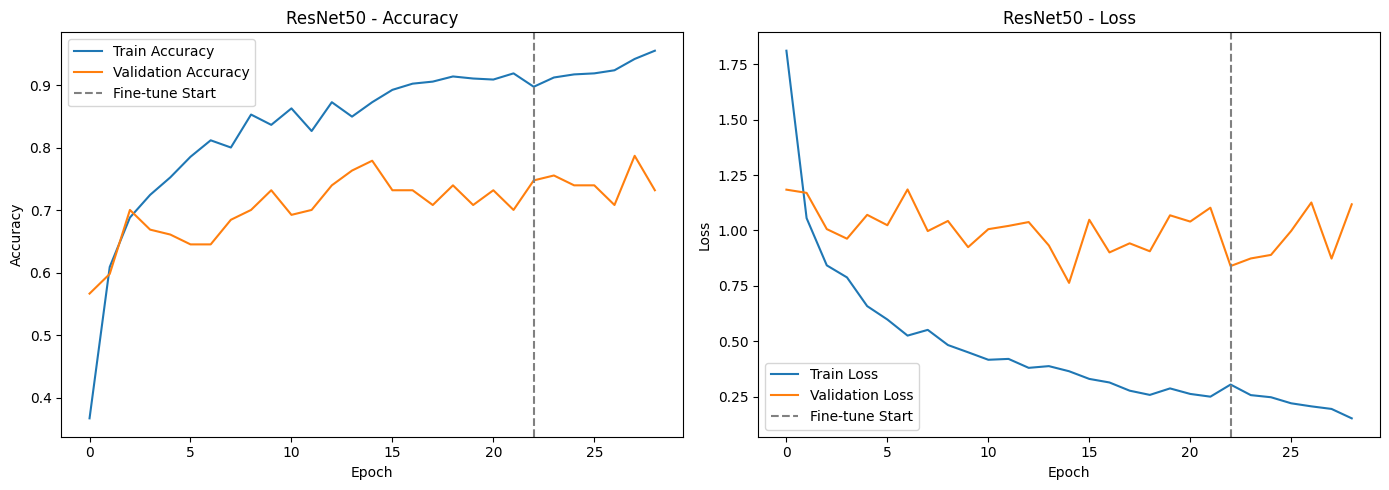

In [16]:
# ============================================
# TRAINING CURVES (accuracy + loss subplots)
# ============================================

import matplotlib.pyplot as plt

acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss_curve = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

fine_tune_start = len(history_phase1.history['accuracy'])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=fine_tune_start, color='gray', linestyle='--', label='Fine-tune Start')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet50 - Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss_curve, label='Validation Loss')
plt.axvline(x=fine_tune_start, color='gray', linestyle='--', label='Fine-tune Start')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet50 - Loss')
plt.legend()

plt.tight_layout()
plt.show()